=== Fuzzy Logic Controller Output ===
Heater Power (%): 81.62
Lamp Brightness (%): 82.38


/opt/anaconda3/envs/anaconda-2025.06-py3.11/lib/python3.11/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


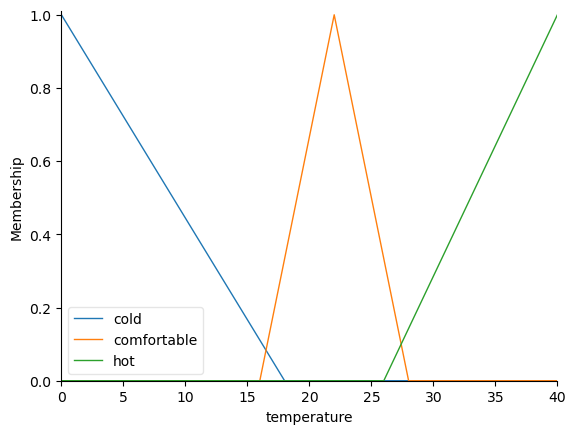

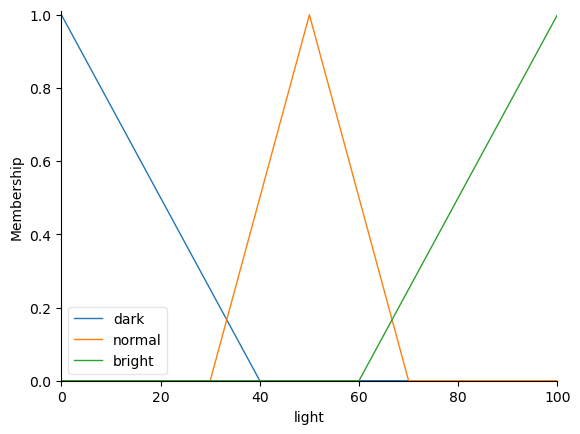

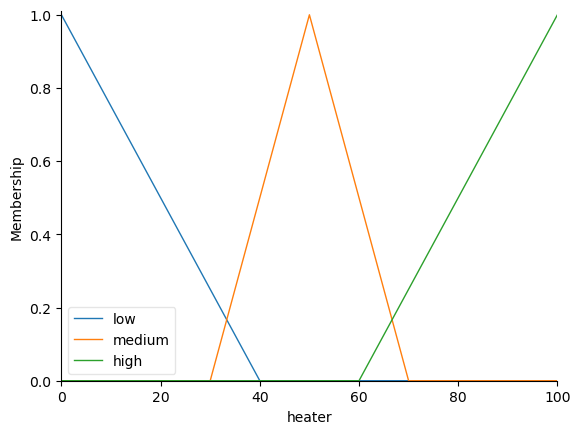

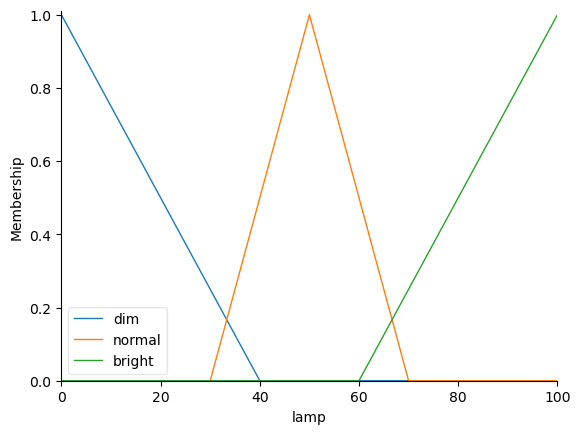

In [1]:
# ============================================================
# TASK 2 – PART 1
# Fuzzy Logic Controller for an Intelligent Assistive Room
# Mamdani Fuzzy Inference System
# ============================================================

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Define Inputs (Sensors)
# ------------------------------------------------------------

temperature = ctrl.Antecedent(np.arange(0, 41, 1), 'temperature')  # °C
light = ctrl.Antecedent(np.arange(0, 101, 1), 'light')             # %

# ------------------------------------------------------------
# 2. Define Outputs (Actuators)
# ------------------------------------------------------------

heater = ctrl.Consequent(np.arange(0, 101, 1), 'heater')           # %
lamp = ctrl.Consequent(np.arange(0, 101, 1), 'lamp')               # %

# ------------------------------------------------------------
# 3. Membership Functions
# ------------------------------------------------------------

temperature['cold'] = fuzz.trimf(temperature.universe, [0, 0, 18])
temperature['comfortable'] = fuzz.trimf(temperature.universe, [16, 22, 28])
temperature['hot'] = fuzz.trimf(temperature.universe, [26, 40, 40])

light['dark'] = fuzz.trimf(light.universe, [0, 0, 40])
light['normal'] = fuzz.trimf(light.universe, [30, 50, 70])
light['bright'] = fuzz.trimf(light.universe, [60, 100, 100])

heater['low'] = fuzz.trimf(heater.universe, [0, 0, 40])
heater['medium'] = fuzz.trimf(heater.universe, [30, 50, 70])
heater['high'] = fuzz.trimf(heater.universe, [60, 100, 100])

lamp['dim'] = fuzz.trimf(lamp.universe, [0, 0, 40])
lamp['normal'] = fuzz.trimf(lamp.universe, [30, 50, 70])
lamp['bright'] = fuzz.trimf(lamp.universe, [60, 100, 100])

# ------------------------------------------------------------
# 4. Rule Base (Mamdani)
# ------------------------------------------------------------

rules = [
    ctrl.Rule(temperature['cold'], heater['high']),
    ctrl.Rule(temperature['comfortable'], heater['medium']),
    ctrl.Rule(temperature['hot'], heater['low']),

    ctrl.Rule(light['dark'], lamp['bright']),
    ctrl.Rule(light['normal'], lamp['normal']),
    ctrl.Rule(light['bright'], lamp['dim'])
]

# ------------------------------------------------------------
# 5. Inference System
# ------------------------------------------------------------

flc_system = ctrl.ControlSystem(rules)
flc = ctrl.ControlSystemSimulation(flc_system)

# ------------------------------------------------------------
# 6. Example Simulation (Operational Scenario)
# ------------------------------------------------------------

flc.input['temperature'] = 15   # cold room
flc.input['light'] = 30         # dark room

flc.compute()

print("=== Fuzzy Logic Controller Output ===")
print(f"Heater Power (%): {flc.output['heater']:.2f}")
print(f"Lamp Brightness (%): {flc.output['lamp']:.2f}")

# ------------------------------------------------------------
# 7. Visualisation (Required for marks)
# ------------------------------------------------------------

temperature.view()
light.view()
heater.view()
lamp.view()

plt.show()


In [3]:
# ============================================================
# TASK 2 – PART 2
# Simple Optimization Comparison (GA vs PSO vs SA)
# ============================================================

import numpy as np
from scipy.optimize import differential_evolution, dual_annealing

# ------------------------------------------------------------
# Benchmark Function (Sphere – from CEC family)
# ------------------------------------------------------------

def sphere(x):
    return np.sum(x**2)

bounds_2d = [(-5, 5), (-5, 5)]
bounds_10d = [(-5, 5)] * 10

# ------------------------------------------------------------
# Genetic Algorithm (Differential Evolution)
# ------------------------------------------------------------

ga_2d = differential_evolution(sphere, bounds_2d)
ga_10d = differential_evolution(sphere, bounds_10d)

# ------------------------------------------------------------
# Simulated Annealing
# ------------------------------------------------------------

sa_2d = dual_annealing(sphere, bounds_2d)
sa_10d = dual_annealing(sphere, bounds_10d)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("=== Optimization Results ===")
print("GA 2D Best:", ga_2d.fun)
print("GA 10D Best:", ga_10d.fun)
print("SA 2D Best:", sa_2d.fun)
print("SA 10D Best:", sa_10d.fun)


=== Optimization Results ===
GA 2D Best: 0.0
GA 10D Best: 0.0
SA 2D Best: 5.0335722708323456e-17
SA 10D Best: 2.4559021789038117e-13
